In [102]:
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.optimize import nnls
import os
import re
import random

import importlib
import cleaning as clean

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif"]

---

A new notebook to complement Liang's approximate Bayesian computing work.

The objective: given the mutational profile of an individuals colon, what is the probability that they had the E.coli bacterial infection?

1. Load the synthetic data. This can be found in `generated_data/` and is split by (a) the number of mutations, and (b) the injection level $\alpha$.

2. Establish a baseline "healthy" colon signature profile (from 0.4, 0.4, 0.2).

3. Play with some ABC estimates: how many mutations do we need? Can we estimate the alpha? 


In [2]:
# Understanding the file name/loading conventions.
str_test = "synthetic_data_mnX_a0.08"
mn, a = str_test[17:].split("_a")
mn, a, a[:-4]

('X', '0.08', '')

In [3]:
# Loading the synthetic data (1).
# ========================

def load_NM_data(mn_get = 10, directory_str = "../generated_data"):
    """ 
    Load the synthetic data.
    NOTE: uses a dictionary instead of a list for easier access.
    Assumes the only lognormal named scheme has alpha = 0.1 (10%).
    Input:
        mn_get (int): the number of mutations.
        directory_str (str): local directory with the csv data.
    Output:

    """
    dfs = {}
    
    # Convert string to directory language?
    directory = os.fsencode(directory_str)
    for file in os.listdir(directory):
        # Convert string from directory language into string?
        filename = os.fsdecode(file)

        # synthetic_data_mnX_aY
        # so the 17th index starts at X.
        mn, a = filename[17:].split("_a")
        a = a[:-4] # Why? But it works?

        # Special case that the file ends in "logn", here always a = 0.1.
        if (len(a) > 4):
            a = 0.1

        if (int(mn) == mn_get):
            # NOTE new, normalise here.
            df_raw = pd.read_csv(os.path.join(directory_str, filename)).iloc[:, 1:]
            dfs[float(a)] = (df_raw / mn_get)


    return dfs

In [4]:
mn_get = 3
dfs_mn3 = load_NM_data(mn_get = mn_get)

print(dfs_mn3.keys())

dict_keys([0.08, 0.1, 0.5, 0.0, 1.0])


In [5]:
dfs_mn3[0.08].head(1)

,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,G[C>A]A,G[C>A]C,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(0.0, 0.4)

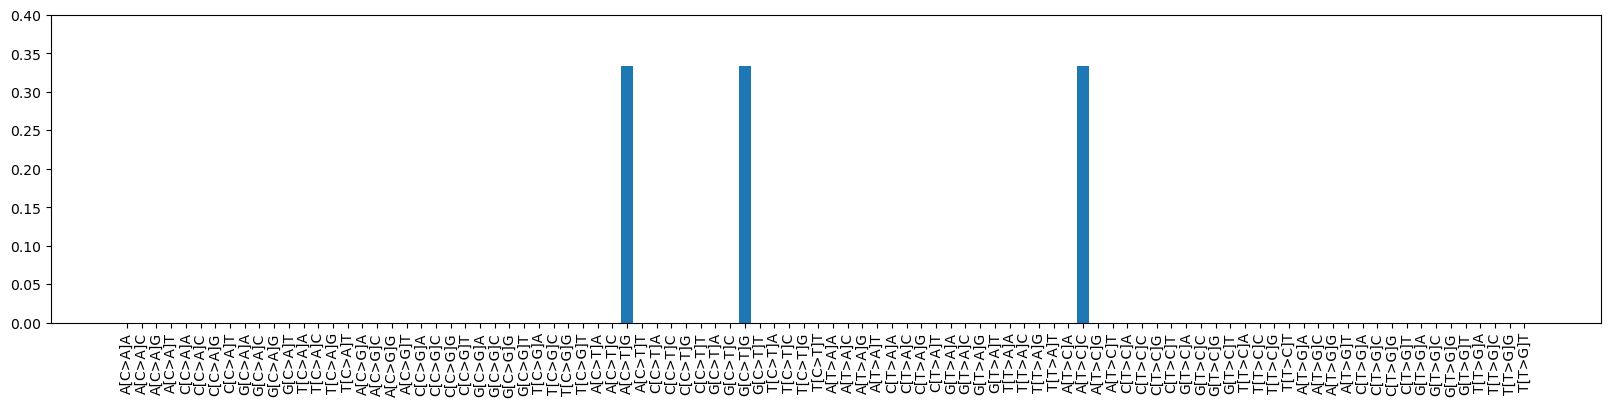

In [6]:
example = dfs_mn3[0.08].iloc[1]
fig, ax = plt.subplots(figsize = (20, 4))
ax.bar(example.index, example)
ax.tick_params(axis = 'x', rotation=90)
ax.set_ylim(top = 0.4)

I think we've been comparing these "three mutations" to the entire probability distribution of the SBS88 profile. This explains (a) why we need the tolerance so high and (b) why we need so many mutations.

Instead, I think(?!) we need to simulate profiles using $N$ the same for both a healthy person and an infected person. 

(0.0, 0.4)

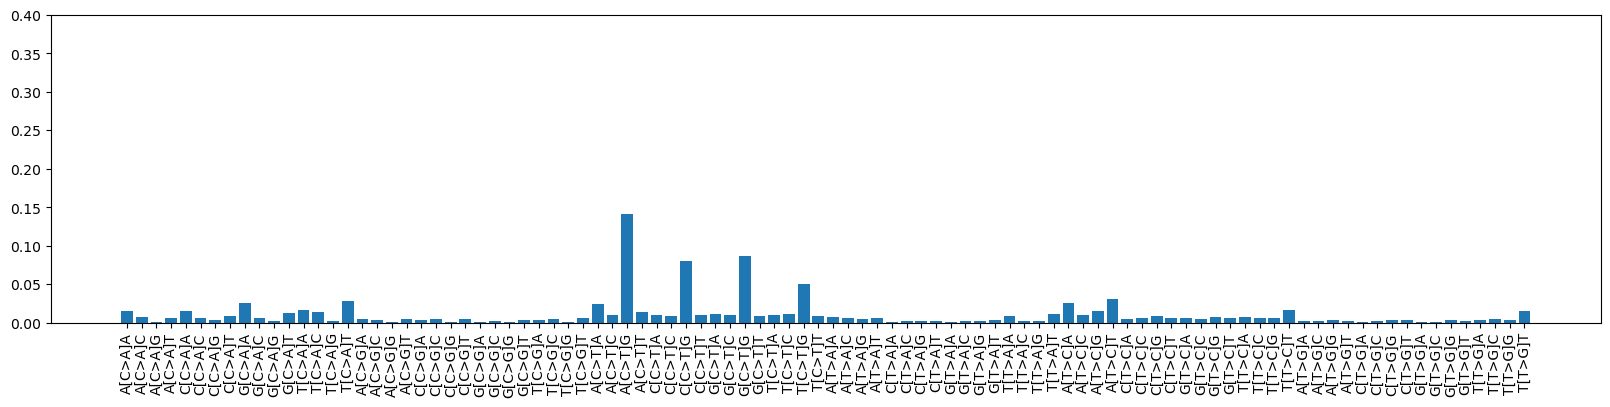

In [7]:
# Example - with N = 10,000 (as is in the synthetic data).
test = dfs_mn3[0.08].copy()
mn3_sum = test.sum()
final = mn3_sum / (mn3_sum.sum())

fig, ax = plt.subplots(figsize = (20, 4))
ax.bar(final.index, final)
ax.tick_params(axis = 'x', rotation=90)
ax.set_ylim(top = 0.4)

---

Looking at Liang's comparisons first, to check.

In [8]:
# Note that the Context labels are not in the same order as in the Webpage.
importlib.reload(clean)

# Load raw data for SBS88, 1, 5, 18.
data_path_signatures = os.path.abspath("../data/Context_SBS_2.txt")
sig_df = pd.read_csv(data_path_signatures, sep = ",")

# Clean.
clean_sig_df = clean.clean_sigs(sig_df)
clean_sig_df.head(1)

,Context,SBS88,SBS1,SBS5,SBS18,Normal,Mutation
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534,0.015456,C>A


In [9]:
# As Liang defines it
reference_sig = clean_sig_df["SBS88"]
print(reference_sig, sum(reference_sig))

0     1.000000e-18
1     1.000000e-18
2     1.000000e-18
3     1.737757e-03
4     1.000000e-18
          ...     
91    1.344195e-02
92    3.016341e-02
93    2.114288e-02
94    1.000000e-18
95    1.024023e-01
Name: SBS88, Length: 96, dtype: float64 0.9999999999999988


(np.float64(0.0001), array([0., 1., 0., ..., 0., 0., 0.]))

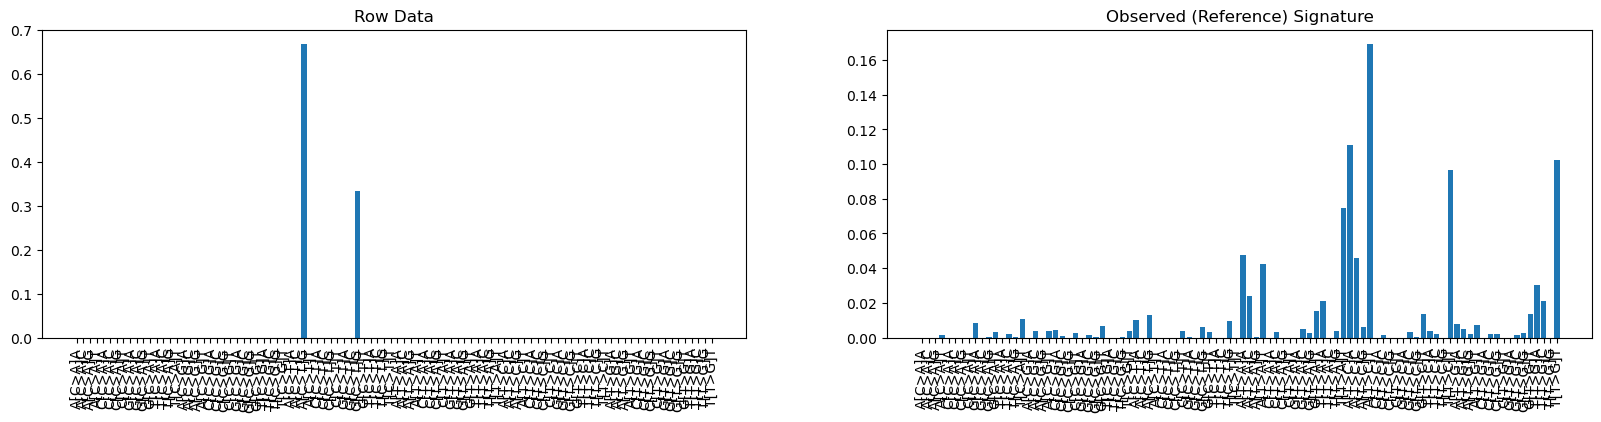

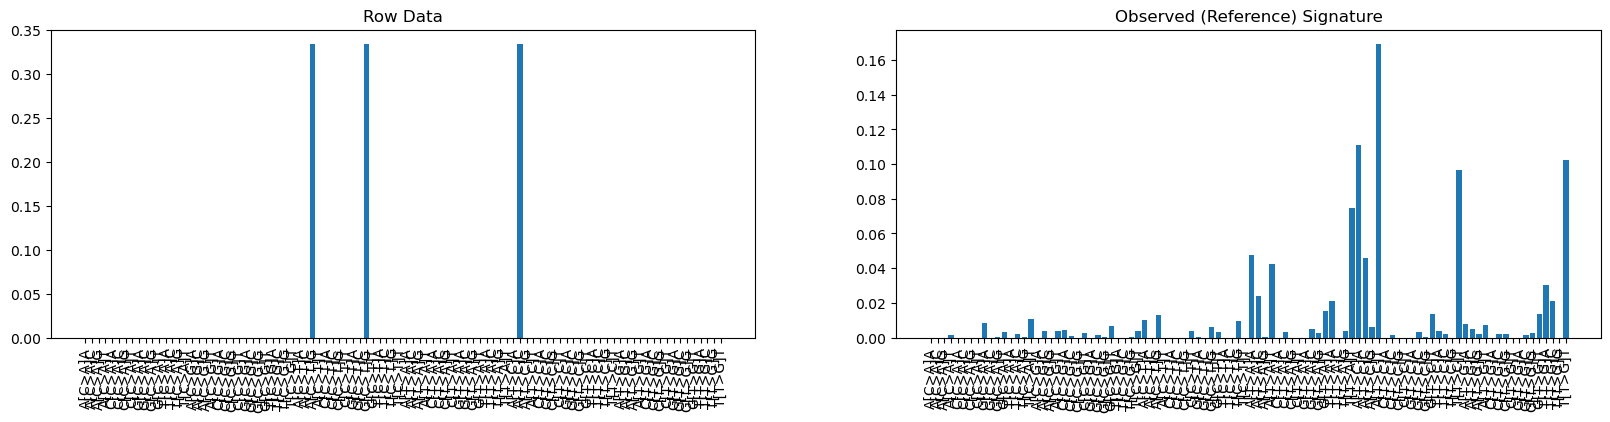

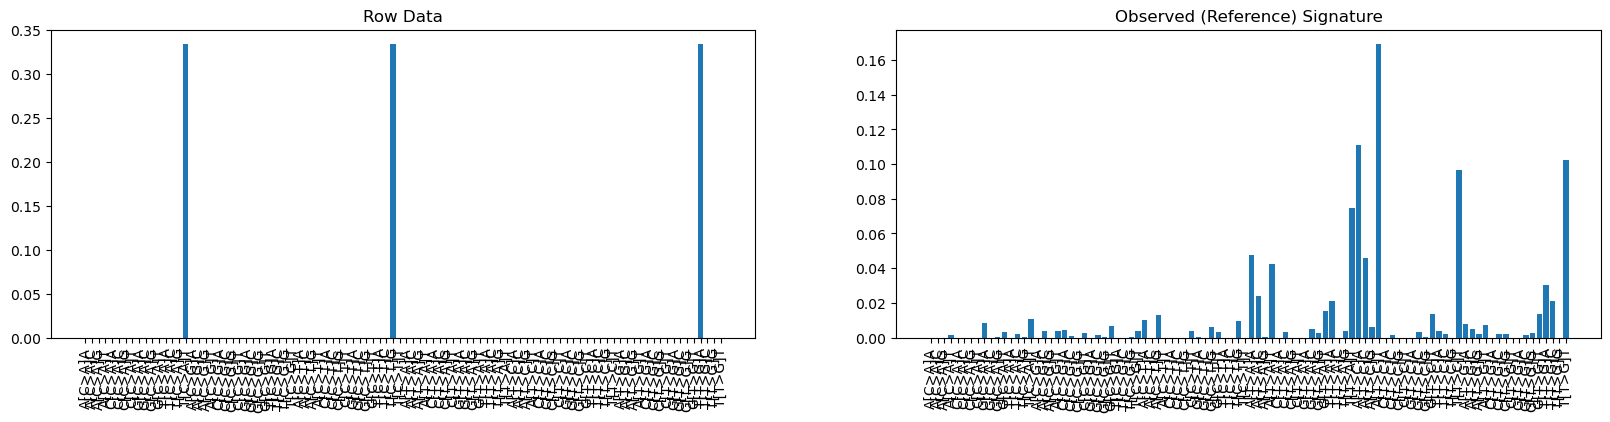

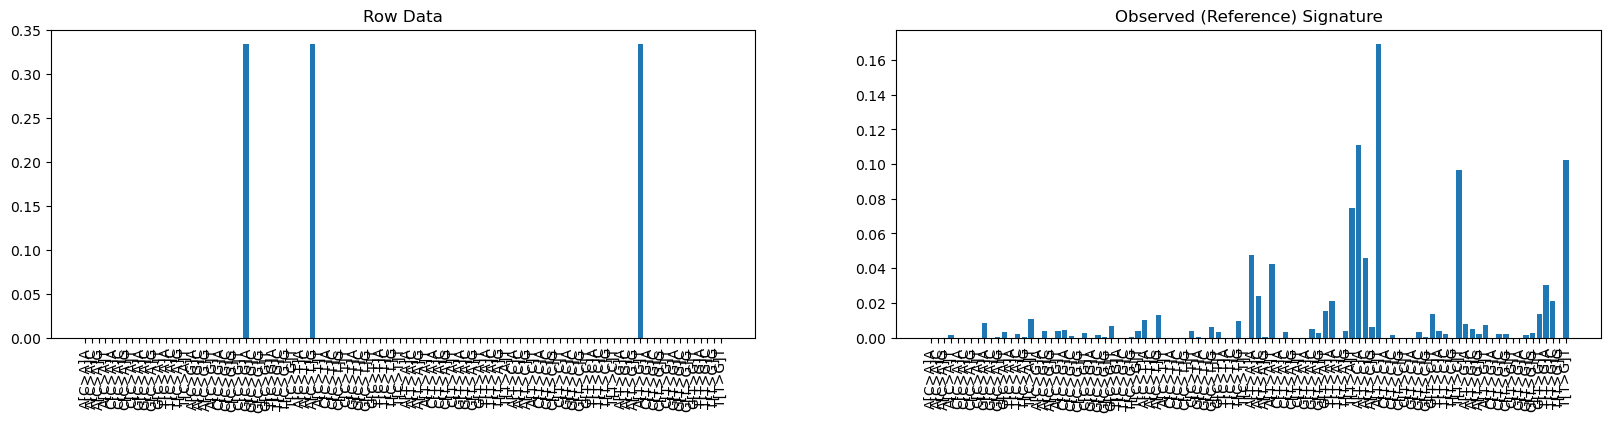

In [62]:
import scipy.spatial.distance as scipy_dist
cos_sim = scipy_dist.cosine
scipy_corr = scipy_dist.correlation

def safe_cos_sim_old(u, v, tol = 1e-8):
    if (np.linalg.norm(u) < tol) or (np.linalg.norm(v) < tol):
        return 1.0
    
    if np.all(u == u[0]) or np.all(v == v[0]):
        print(f"Culprit 1")
        return 1.0  

    elif np.std(u) < tol or np.std(v) < tol:
        print(f"Culprit 2")
        return 1.0
    
    elif np.any(~np.isfinite(u)) or np.any(~np.isfinite(v)):
        print(f'INFINITE VALUE!')
    
    # hhh
    return cos_sim(u, v)

def safe_cos_sim(u, v, tol = 1e-15):
    # Ensure we are using float64 to minimize rounding errors.
    u = np.asarray(u, dtype=np.float64)
    v = np.asarray(v, dtype=np.float64)

    # Calculate variance manually to check for "constant" vectors.
    if np.var(u) < tol or np.var(v) < tol:
        return 1.0 

    try:
        # SciPy's correlation is 1 - pearson_r
        return scipy_corr(u, v)
    except ValueError:
        # If we still hit a domain error, it's a precision ghost
        # Return 1.0 (no distance) or 0.0 (perfect similarity) 
        # based on your needs
        return 1.0

def ABC_for_known_data(df_data, obs_sig, f_comparison = safe_cos_sim, tol = 0.95):
    # Store accept (1) and reject (0)
    classifications = np.zeros(len(df_data))

    for i, row in df_data.iterrows():
        if (i > 3):
            continue 
        
        # For each row compare to the obs_signature
        contexts = row.index
        fig, axes = plt.subplots(1, 2, figsize = (20, 4))
        ax1, ax2 = axes 

        ax1.bar(contexts, row); ax1.set_title("Row Data")
        ax2.bar(contexts, obs_sig); ax2.set_title("Observed (Reference) Signature")
        
        for ax in axes:
            ax.tick_params(axis = "x", rotation = 90)

        difference_score = f_comparison(obs_sig, row)

        # print(difference_score)
        if (difference_score < tol):
            classifications[i] = 1

    # End loop
    rejects_perc = np.sum(classifications)/len(classifications)
    return rejects_perc, classifications

# ================

test_alpha = 0.08
ABC_for_known_data(dfs_mn3[test_alpha], reference_sig)

---
---
---

Methodology.

Let a healthy person have mutations occur in their colon according to the probability distribution defined by 
$$H = 0.4SBS_1 + 0.4SBS_5 + 0.2SBS_{18}.$$
Let an infected person have mutations occur in their colon according to the probability distribution $\alpha SBS_{88} + (1 - \alpha)H$.

1. We need a way to simulate mutational profiles for $N$ mutations, i.e. a realisation of both the healthy and infected probability distributions for a sample size $N$.

2. For each $N$, run a batch of trials $B = 10$ that compare the healthy and infected mutational profiles. Are they similar? Use cosine similarity. 

In [11]:
alpha = 0.0843
clean_sig_df["Infected"] = alpha*clean_sig_df["SBS88"] + (1 - alpha)*clean_sig_df["Normal"]
healthy_weights = clean_sig_df["Normal"]
infected_weights = clean_sig_df["Infected"]

# Check the distributions are normal.
print(clean_sig_df["Infected"].sum(), clean_sig_df["Normal"].sum())

0.9999999999999973 0.9999999999999971


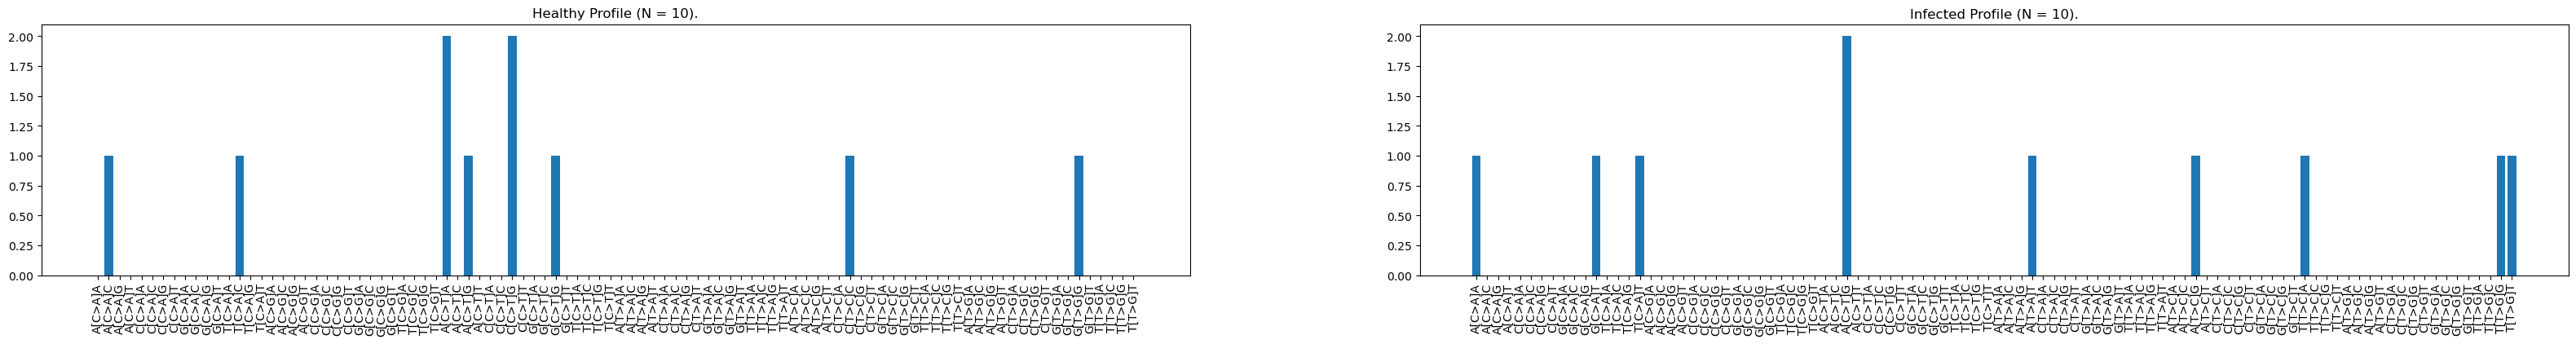

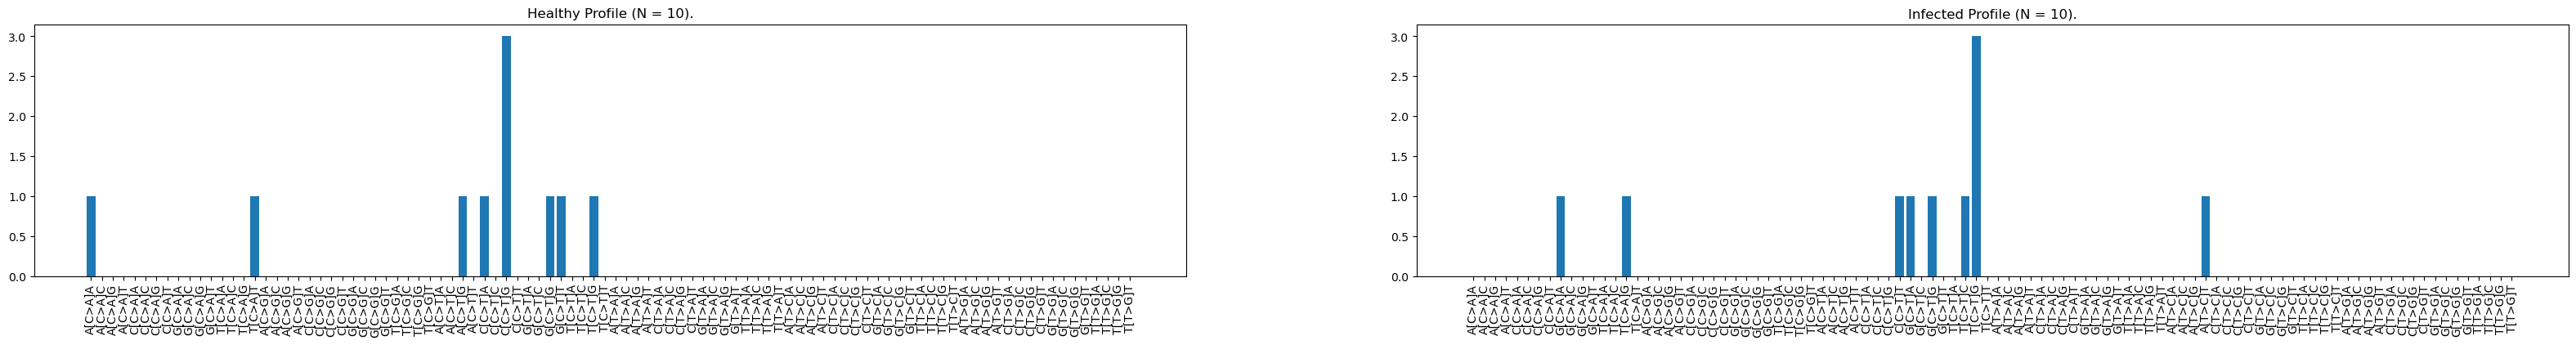

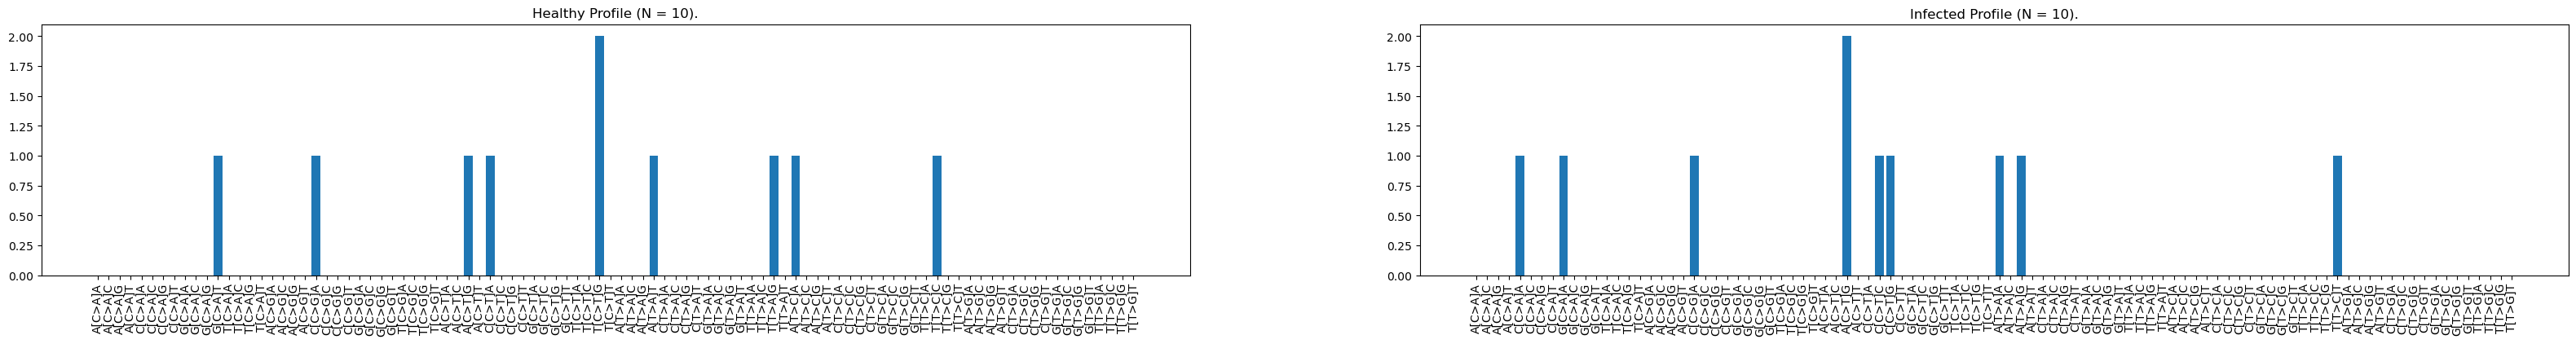

In [12]:
# The "Normal" column is the probability distribution H.
def generate_profiles(healthy_weights, infected_weights, N):
    """ 
    Generates mutational profiles exhibiting N mutations according to
    the healthy and infected probability distributions.
    """

    # https://numpy.org/doc/2.2/reference/random/generated/numpy.random.multinomial.html
    healthy_profile = np.random.multinomial(N, healthy_weights)
    infected_profile = np.random.multinomial(N, infected_weights)

    return healthy_profile, infected_profile 

# ===============================================================

healthy_weights = clean_sig_df["Normal"]
infected_weights = clean_sig_df["Infected"]
contexts = clean_sig_df["Context"]
N_test = 10

for j in range(3):
    fig, axes = plt.subplots(1, 2, figsize = (40, 4))
    ax1, ax2 = axes 

    h_profile, i_profile = generate_profiles(healthy_weights, infected_weights, N_test)
    ax1.bar(contexts, h_profile); ax1.set_title(f"Healthy Profile (N = {N_test}).")
    ax2.bar(contexts, i_profile); ax2.set_title(f"Infected Profile (N = {N_test}).")

    for ax in axes:
        ax.tick_params(axis = "x", rotation = 90)
    
    plt.show()

Here we start the theory with approximate Bayesian computing. We have a way to generate healthy and infected profiles (with fixed $\alpha = 0.0843$, for now). Try with $N = 10k$ for $k = 1, 2, \dots, 50$ - so max number of mutations is $50$.

What is the best tolerance? To look at this, we'll plot the cosine similarity between healthy-healthy signatures and healthy-infected signatures.

In [13]:
# Check cosine similarity values.
# Should be: 0 is identical, 1 is orthogonal.
v1 = [1, 0, 0]
v2 = [1, 0, 0]
v3 = [0, 1, 0]
v4 = [1, 1, 0]
cos_sim(v1, v2), cos_sim(v1, v3), cos_sim(v1, v4)

(np.float64(0.0), np.float64(1.0), np.float64(0.29289321881345254))

In [63]:
def generate_profile(weights, N):
    """ 
    Modification to `generate_profiles()` that generates both - here we only generate one.
    """
    profile = np.random.multinomial(N, weights)
    return profile 

# =====================================================


def compute_similarity(N_muts, healthy_sig, weights, f_comparison = safe_cos_sim, B = 1000):
    """  
    Computes the similarity between a given healthy signature and the average of B 
    synthetically produced signatures with weights `weights` and N_muts mutations.
    """

    scores = np.zeros(B)
    for j in range(B):
        synthetic_sig = generate_profile(weights, N_muts)
        scores[j] = f_comparison(healthy_sig, synthetic_sig)
    
    return scores

In [15]:
N_range = [10*k for k in range(1, 50 + 1)]
healthy_healthy_avg = np.zeros_like(N_range)
batches = 500
healthy_healthy_scores = np.zeros((len(N_range), batches))
healthy_infected_scores = np.zeros((len(N_range), batches))

num_comparisons = 10

for j, N_muts in enumerate(N_range):
    healthy_healthy_score = 0
    healthy_infected_score = 0

    for k in range(num_comparisons):
        # Random healthy signature for comparison.
        healthy_sig = generate_profile(healthy_weights, N_muts)
        healthy_healthy_score += compute_similarity(N_muts, healthy_sig, healthy_weights, B = batches)
        healthy_infected_score += compute_similarity(N_muts, healthy_sig, infected_weights, B = batches)

    healthy_healthy_scores[j] = healthy_healthy_score / num_comparisons
    healthy_infected_scores[j] = healthy_infected_score / num_comparisons

# ================================================================
df_healthy = pd.DataFrame(healthy_healthy_scores.T, columns = N_range).melt(
    var_name = "N", value_name = "cosine_distance")
df_healthy["comparison"] = "HH"

df_infected = pd.DataFrame(healthy_infected_scores.T, columns = N_range).melt(
    var_name = "N", value_name = "cosine_distance")
df_infected["comparison"] = "HI"

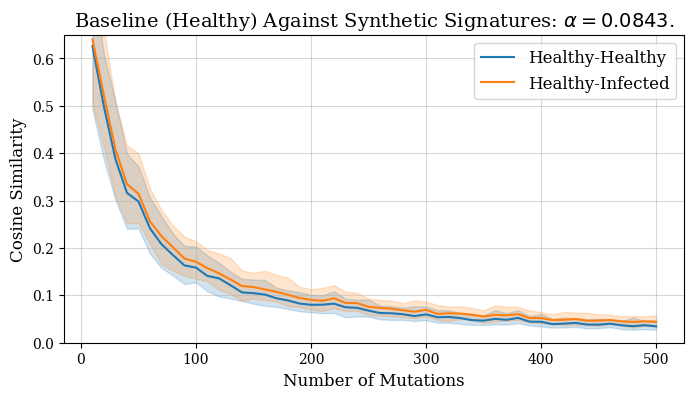

In [106]:
# Plot
fig, ax = plt.subplots(figsize = (8, 4))
sns.lineplot(data = df_healthy, x = "N", y = "cosine_distance", ax = ax, errorbar = ("pi", 100), label = "Healthy-Healthy")
sns.lineplot(data = df_infected, x = "N", y = "cosine_distance", ax = ax, errorbar = ("pi", 100), label = "Healthy-Infected")

ax.legend(loc = "upper right", fontsize = 12)
ax.set_xlabel("Number of Mutations", fontsize = 12)
ax.set_ylabel("Cosine Similarity", fontsize = 12)
ax.set_title(r"Baseline (Healthy) Against Synthetic Signatures: $\alpha = 0.0843$.", fontsize = 14)
ax.set_ylim(0, 0.65)
ax.grid(alpha = 0.5)

plt.show()

In [ ]:
def ABC_classification(N_muts, healthy_sig, weights,
                       f_comparison = safe_cos_sim, B = 1000, tol = 0.25):
    """ 
    Gives a rejection score to the hypothesis 
        "two signatures with N_muts mutation have been derived from the same distribution".
        
    The weights determining these distributions are given.
        *Really, we are investigating how many mutations are needed to consistently differentiate between the two.
    
    The probability is determined from B batches (higher B for more power).
    The tolerance should be tuned accordingly later.
    """ 

    # Binary 0 = reject, 1 = accept (that they are coming from the same dist).
    rejects = np.zeros(B)
    for j in range(B):
        synthetic_sig = generate_profile(weights, N_muts)
        difference_score = f_comparison(healthy_sig, synthetic_sig)

        # Tolerance should be tuned.
        # 0 means identical, 1 means orthogonal.
        if (difference_score > tol):
            rejects[j] = 1

    # End loop.
    percentage_reject = np.sum(rejects) / B 
    return percentage_reject

# ============================================

# Tune for tolerance.
N_range = [10*k for k in range(1, 50 + 1)] # So 10, 20, ..., 500
tol_range = [0.05*k for k in range(1, 10 + 1, 2)] # So 0.05, 0.1, ..., 0.5
N_rejects_rate = np.zeros((len(tol_range), len(N_range)), dtype = np.float64)

for j, N_muts in enumerate(N_range):
    # Draw the healthy signature.
    healthy_sig = generate_profile(healthy_weights, N_muts)

    # Compare for different tolerance thresholds.
    for k, tol in enumerate(tol_range):
        N_rejects_rate[k][j] = ABC_classification(N_muts, healthy_sig, infected_weights, tol = tol)

**Rejection means they are NOT coming from the same distribution.**

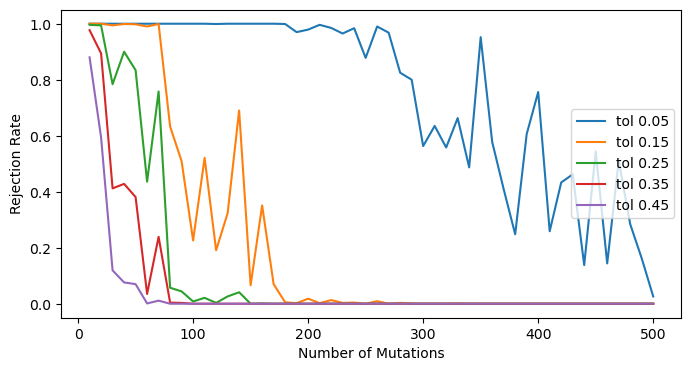

In [18]:
fig, ax = plt.subplots(figsize = (8, 4))
for j, tol in enumerate(tol_range):
    N_rejects = N_rejects_rate[j]
    ax.plot(N_range, N_rejects, label = f"tol {round(tol, 2)}")

ax.set_xlabel("Number of Mutations")
ax.set_ylabel("Rejection Rate")
ax.legend(loc = "center right")

plt.show()

Rejection rate decreases with tolerance, as expected. We can make the tolerance better by comparing the scores from an injected-healthy split to a healthy-healthy split. The tolerance needs to classify healthy-healthy as the same (low rejection rate), whilst keeping infected-healthy different (high rejection rate).

In [ ]:
N_rejects_diff = np.zeros((len(tol_range), len(N_range)), dtype = np.float64)
N_rejects_same = np.zeros((len(tol_range), len(N_range)), dtype = np.float64)

for k, tol in enumerate(tol_range):
    for j, N_muts in enumerate(N_range):
        # Generate a healthy observation for comparison.
        healthy_obs = generate_profile(healthy_weights, N_muts)

        # SAME weights (healthy - healthy)
        same_same = ABC_classification(N_muts, healthy_obs, healthy_weights, tol = tol)
        # print(f'Same-Same {same_same} rejection rate.')
        N_rejects_same[k][j] = same_same

        # DIFFERENT weights (healthy - infected)
        N_rejects_diff[k][j] = ABC_classification(N_muts, healthy_obs, infected_weights, tol = tol)

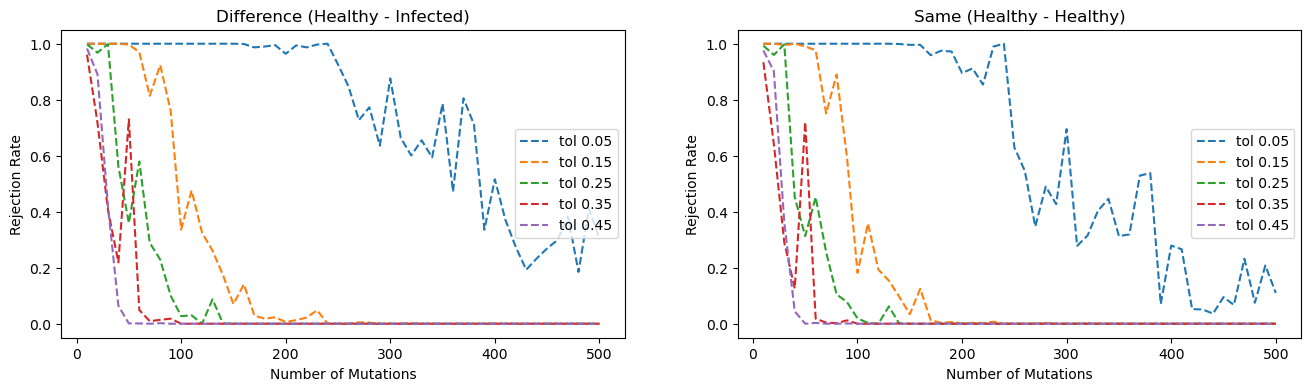

In [20]:
fig, axes = plt.subplots(1, 2, figsize = (16, 4))
ax1, ax2 = axes
for j, tol in enumerate(tol_range):
    N_diff = N_rejects_diff[j]
    N_same = N_rejects_same[j]
    
    ax1.plot(N_range, N_diff, linestyle = "--", label = f"tol {round(tol, 2)}")
    ax1.set_title("Difference (Healthy - Infected)")

    ax2.plot(N_range, N_same, linestyle = "--", label = f"tol {round(tol, 2)}")
    ax2.set_title("Same (Healthy - Healthy)")
    
for ax in axes:
    ax.set_xlabel("Number of Mutations")
    ax.set_ylabel("Rejection Rate")
    ax.legend(loc = "center right")

plt.show()

Think more about how you interpret these plots!

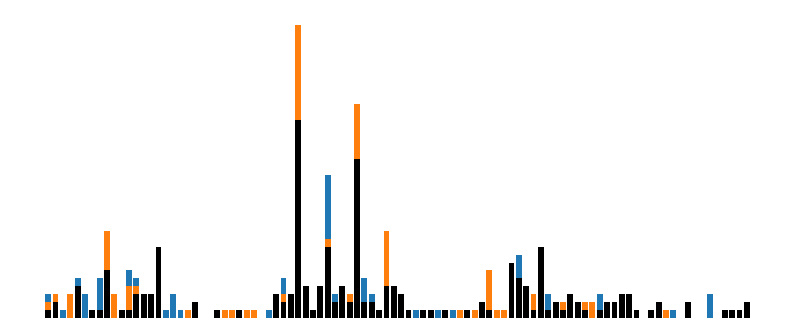

In [21]:
test_profile_1 = generate_profile(healthy_weights, N = 200)
test_profile_2 = generate_profile(healthy_weights, N = 200)
test_profile_3 = generate_profile(infected_weights, N = 200)

fig, ax = plt.subplots(figsize = (10, 4))
ax.bar(contexts, test_profile_1)
ax.bar(contexts, test_profile_2)
ax.bar(contexts, test_profile_3, color = "black")
ax.set_axis_off()

plt.show()

In [22]:
cos_sim(test_profile_1, test_profile_2), cos_sim(test_profile_1, test_profile_3)

(np.float64(0.1408507158069766), np.float64(0.1553461610827095))

Tune the tolerance for the best $J$-statistic (TPR - FPR).
1. For each number of mutations $nm$, average the TPR against $10$ healthy baselines, and also the FPR, for a varying tolerance (maybe $0.05$ steps between $[0, 1]$).
2. Using the averaged TPR and averaged FPR, find the best $J$ statistic for that tolerance. Store the best $J$ and the corresponding $tol$.
3. Repeat for each number of mutations.

In [23]:
testarr = np.array([1, 2, 3, 4])
(testarr > 2).sum()

np.int64(2)

In [43]:
def find_best_tols(N_range, tol_range, healthy_weights, infected_weights, num_comparisons = 5, batches = 500):
    """  
    Find the best tolerance to classify models using ABC.
    Returns a list of tolerances corresponding to that N_range.
    """

    best_tols = np.zeros_like(N_range, dtype = np.float64)
    best_Js = np.zeros_like(N_range, dtype = np.float64)

    for j, N_muts in enumerate(N_range):
        # Each mutation: try all of the tolerances.
        tol_best = 0
        J_best = 0

        for tol in tol_range:
            J_tol = 0

            # Average across 10 healthy baselines.
            for k in range(num_comparisons):
                healthy_reference = generate_profile(healthy_weights, N_muts)
                # Cosine similarities to the healthy signatures.
                healthy_similarities = compute_similarity(N_muts, healthy_reference, healthy_weights,
                                            B = batches)
                infected_similarities = compute_similarity(N_muts, healthy_reference, infected_weights,
                                            B = batches)
                
                # How many are correct?
                # Cosine similarity: 0 is same, 1 is not.
                # We're using a rejection based algorithm.
                # True positives: healthy < tol.
                healthy_correct = ((healthy_similarities < tol).sum() / batches)

                # False positives: infected < tol.
                infected_incorrect = ((infected_similarities < tol).sum() / batches)

                # TPR - FPR (Youden's J statistic).
                J = healthy_correct - infected_incorrect
                J_tol += J 

            # Average the J
            J_tol = J_tol / num_comparisons
            if (J_tol > J_best):
                J_best = J_tol
                tol_best = tol

        # Store the best tols/J per iteration.
        best_tols[j] = tol_best 
        best_Js[j] = J_best

    return best_tols, best_Js

In [34]:
N_range1 = [10] + [10*k for k in range(5, 75, 5)] # 10, 50, 100
tol_range1 = np.arange(0.025, 0.15 + 0.025, 0.025) 
best_tols1, best_Js1 = find_best_tols(N_range1, tol_range1, healthy_weights, infected_weights)

In [35]:
def plot_tol_range(N_range, best_tols, best_Js, save = False):

    fig, ax = plt.subplots(figsize = (8, 4))

    line1 = ax.plot(N_range, best_tols, marker = "x", color = "red", label = "Tolerance")
    ax.set_xlabel("Number of Mutations", fontsize = 12)
    ax.set_ylabel(r"Tolerance $\alpha$", fontsize = 12)

    ax2 = ax.twinx()
    line2 = ax2.plot(N_range, best_Js, marker = "^", color = "blue", label = "$J$-statistic")
    ax2.set_ylabel("$J$-statistic (TPR - FPR)", fontsize = 12)

    lines = line1 + line2
    labs = [l.get_label() for l in lines]
    ax.legend(lines, labs, loc = "upper left", fontsize = 14)
    ax.set_title(r"Optimal tolerance $\alpha$ against the number of mutations.", fontsize = 14)

    if (save):
        randint = np.random.randint(0, 1000)
        plt.savefig(f"../../image{randint}.png", format = "png", dpi = 200)
    else:
        plt.show()

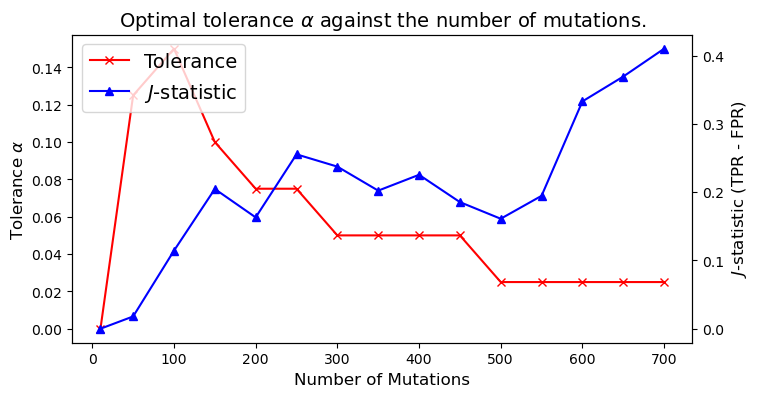

In [36]:
plot_tol_range(N_range1, best_tols1, best_Js1, save = False)

In [ ]:
# ORIGINAL before function was made.
# =================================

# N_range = [10*k for k in range(1, 75)] # 10, 20, ..., 1000.
# tol_range = np.arange(0.025, 0.3, 0.025) # 0.025, 0.05, 0.075, 0.1, ..., 0.3
# num_comparisons = 10
# batches = 1000

#

Have the ability to tune the tolerance.

1. Vary $\alpha \in \{0.08, 0.1, 0.5, 1\}$ where $0.1$ is lognormal.

In [ ]:
def ABC_classification(N_muts, healthy_sig, weights,
                       f_comparison = safe_cos_sim, B = 1000, tol = 0.25):
    """ 
    Gives a rejection score to the hypothesis 
        "two signatures with N_muts mutation have been derived from the same distribution".
        
    The weights determining these distributions are given.
        *Really, we are investigating how many mutations are needed to consistently differentiate between the two.
    
    The probability is determined from B batches (higher B for more power).
    The tolerance should be tuned accordingly later.
    """ 

    # Binary 0 = reject, 1 = accept (that they are coming from the same dist).
    rejects = np.zeros(B)
    for j in range(B):
        synthetic_sig = generate_profile(weights, N_muts)
        difference_score = f_comparison(healthy_sig, synthetic_sig)

        # Tolerance should be tuned.
        # 0 means identical, 1 means orthogonal.
        if (difference_score > tol):
            rejects[j] = 1

    # End loop.
    percentage_reject = np.sum(rejects) / B 
    return percentage_reject

# ============================================

def ABC_sbs88_recovery(alphas, N_range):
    """ 
    For each alpha, calculate the best score in sbs88 recovery (TPR - FPR).
    1. Loop each alpha.
    2. For each alpha, loop the N_range from 5, 50, 100, 500, 1000.
    3. Find the best Js according to the other function.
    """

    healthy_weights = clean_sig_df["Normal"]
    Js = np.zeros((len(alphas), len(N_range)), dtype = np.ndarray)

    for k, alpha in enumerate(alphas):
       infected_weights = alpha*clean_sig_df["SBS88"] + (1 - alpha)*clean_sig_df["Normal"]  #
       tol_range = np.arange(0.025, 0.4, 0.025)
       best_tols, best_Js = find_best_tols(N_range, tol_range, healthy_weights, infected_weights)

       Js[k] = best_Js


    return Js

In [113]:
alpha_test = [0.08, 0.1, 0.5, 1]
N_range2 = [5, 50, 100, 500, 1000, 5000]
Js = ABC_sbs88_recovery(alpha_test, N_range = N_range2)

In [115]:
print(Js)

[[0.014800000000000002 0.09559999999999999 0.1528 0.2408 0.3524 0.0]
 [0.009600000000000001 0.148 0.13640000000000002 0.4436 0.6564
  0.00040000000000000034]
 [0.0188 0.6516 0.966 1.0 1.0 1.0]
 [0.0196 0.7688 0.9955999999999999 1.0 1.0 1.0]]


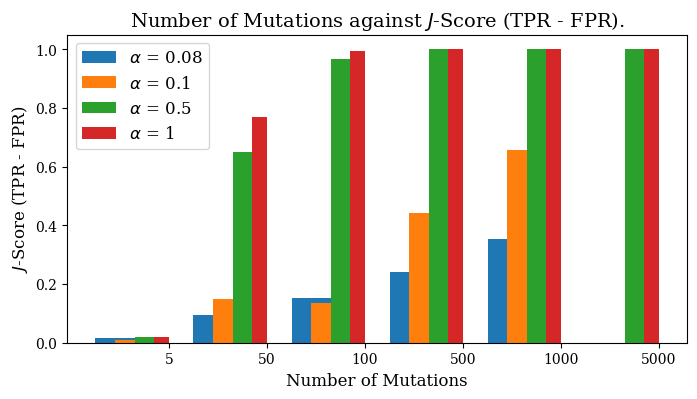

In [114]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif"]

fig, ax = plt.subplots(figsize = (8, 4))
widths = np.array([0.75, 0.55, 0.35, 0.15])

for k, alpha in enumerate(alpha_test):
    ax.bar(np.asarray(N_range2, str), Js[k], width = -1*widths[k], label = fr"$\alpha$ = {alpha}",
            align = "edge", alpha = 1)

ax.set_xlabel("Number of Mutations", fontsize = 12, fontname = "DejaVu Serif")
ax.set_ylabel("$J$-Score (TPR - FPR)", fontsize = 12)
ax.legend(loc = "upper left", fontsize = 12)
ax.set_title("Number of Mutations against $J$-Score (TPR - FPR).", fontsize = 14)

if (False):
    plt.savefig("../../fig2.png", format = "png", dpi = 200)

plt.show()

In [38]:
clean_sig_df.head(1)

,Context,SBS88,SBS1,SBS5,SBS18,Normal,Mutation,Infected
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534,0.015456,C>A,0.014153


In [39]:
type(np.array([1, 2, 3]))

numpy.ndarray